# The Individual Correlates of the Trump Vote (2016)

## 📊 Opis datasetu

Ten zbiór danych pochodzi z badania **Cooperative Congressional Election Study (CCES) 2016** i opisuje indywidualne cechy respondentów w USA oraz ich deklarowane głosowanie w wyborach prezydenckich 2016.

Dataset jest często używany do analizy, jakie czynniki demograficzne, społeczne i ideologiczne wpływają na poparcie dla Donalda Trumpa.

Źródło:  
https://www.kaggle.com/datasets/utkarshx27/the-individual-correlates-of-the-trump-vote

---

## 📁 Struktura danych

Zbiór zawiera ok. **64 600 obserwacji** i **21 zmiennych**.

Najważniejsze zmienne:

### 🎯 Zmienna docelowa
- `votetrump` → 1 jeśli respondent głosował na Donalda Trumpa, 0 w przeciwnym przypadku

### 👤 Dane demograficzne
- `age` → wiek respondenta
- `female` → 1 = kobieta, 0 = mężczyzna
- `racef` → rasa respondenta
- `state` → stan USA
- `collegeed` → wykształcenie (ukończone studia = 1)

### 🧠 Zmienne polityczne i społeczne
- `ideo` → ideologia (od liberalnej do konserwatywnej)
- `pid7na` → identyfikacja partyjna (Demokrata–Republikanin)
- `religimp` → ważność religii
- `bornagain` → chrześcijanin „born-again”

### 🧾 Zmienne społeczne i psychologiczne
- `whiteadv` → przekonanie o przywilejach białych
- `fearraces` → lęk międzyrasowy
- `angryracism` → postawa wobec rasizmu
- `racerare` → przekonanie, że rasizm jest rzadki
---

In [1]:
import pandas as pd,seaborn,numpy
import matplotlib.pyplot as plt

df = pd.read_csv(
    'data.csv')
print("Przed usunięciem wartości pustych:",df.shape)
df.dropna(inplace=True)
print("Po usunieciu: ",df.shape)




Przed usunięciem wartości pustych: (64600, 22)
Po usunieciu:  (37591, 22)


In [2]:
#Downcasting
mem_before = df.memory_usage(deep=True).sum()/1e6
print(f'Pamięć przed optymalizacją: {mem_before} MB')


bool_cols = [
    "votetrump",
    "female",
    "collegeed",
    "bornagain"
]

category_cols = [
    "state",
    "racef",
    "famincr"
]

int_cols = [
    "age",
    "ideo",
    "pid7na",
    "religimp",
    "churchatd",
    "prayerfreq",
    "angryracism",
    "whiteadv",
    "fearraces",
    "racerare"
]

float_cols = [
    "lrelig",
    "lcograc",
    "lemprac"
]

df[bool_cols] = df[bool_cols].astype("bool")
df[category_cols] = df[category_cols].astype("category")
df[int_cols] = df[int_cols].astype("Int8")
df[float_cols] = df[float_cols].astype("float32")

mem_after=df.memory_usage(deep=True).sum()/ 1e6
print(f'Po opytymalizacji: {mem_after} MB')
print(f'Oszczędność: {100*(1- (mem_after/mem_before)):.1f}%')

Pamięć przed optymalizacją: 10.514656 MB
Po opytymalizacji: 2.371724 MB
Oszczędność: 77.4%


Feature engineering
Do naszego datasetu dodamy średnią wieku głosujących na Trumpa oraz nie grupując po stanie 

In [ ]:
trump_voter_mean_age_by_state = df[df["votetrump"]].groupby("state")["age"].mean()
hillary_voter_mean_age_by_state = df[df["votetrump"] == 0].groupby("state")["age"].mean()
trump_voter_age_gap= trump_voter_mean_age_by_state - hillary_voter_mean_age_by_state
df["trump_voter_age_gap_by_state"] = df["state"].map(
    trump_voter_age_gap)
voter_mean_age_by_state = df[df["votetrump"] or df["votetrump"] == 0].groupby
("state")["age"].mean()
df["mean_voter_age_by_state"]=df["state"].map(
    voter_mean_age_by_state
)
df.head()

,rownames,uid,state,votetrump,age,female,collegeed,racef,famincr,ideo,...,whiteadv,fearraces,racerare,lrelig,lcograc,lemprac,voted_trump_mean_age_per_state,trump_voter_mean_age_by_state,hillary_voter_mean_age_by_state,trump_voter_age_gap_by_state
4,5,5,Colorado,False,34,True,True,White,7.0,2,...,1,1,1,-1.130175,-1.204085,-0.138715,54.022305,54.022305,49.819512,4.202793
6,7,7,Texas,True,54,False,False,White,3.0,5,...,5,2,2,1.171097,0.508762,0.204095,55.021719,55.021719,48.545455,6.476264
8,9,9,Georgia,True,53,False,False,White,4.0,4,...,4,1,2,-0.263387,0.301278,0.070166,54.060362,54.060362,49.644628,4.415734
9,10,10,Pennsylvania,True,59,True,False,White,7.0,3,...,5,1,3,-0.066305,0.900038,0.070166,53.458376,53.458376,49.165775,4.292601
10,11,11,Hawaii,False,70,True,True,Asian,10.0,3,...,2,3,2,-0.465141,-0.118812,0.052228,58.150000,58.150000,51.253521,6.896479


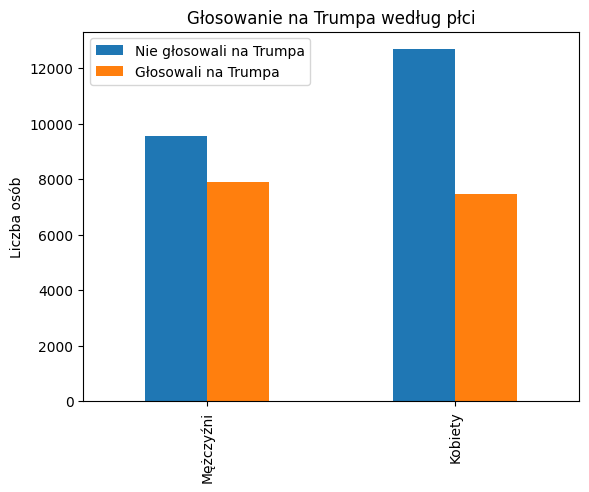

In [23]:


table=pd.crosstab(df["female"],df["votetrump"])
table.index=["Mężczyźni","Kobiety"]
table.columns=["Nie głosowali na Trumpa","Głosowali na Trumpa"]

table.plot(kind="bar")
plt.ylabel("Liczba osób")
plt.title("Głosowanie na Trumpa według płci")
plt.show()

Podobna liczba kobiet i mężczyzn głosowała na Trumpa